In [41]:
# Uncomment if needed

!pip install -q imbalanced-learn ctgan sdv

In [42]:
!pip install -q catboost

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ctgan import CTGAN

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

In [43]:
PROJECT_DIR="/content/drive/MyDrive/Ghana_Dropout_Project"

train_df=pd.read_csv(
    f"{PROJECT_DIR}/train_real.csv"
)

test_df=pd.read_csv(
    f"{PROJECT_DIR}/test_real.csv"
)

TARGET="dropout_label"

X_train=train_df.drop(columns=[TARGET])

y_train=train_df[TARGET]

X_test=test_df.drop(columns=[TARGET])

y_test=test_df[TARGET]

print(train_df.shape)
print(test_df.shape)

(800, 41)
(200, 41)


In [44]:
print("Training")

print(y_train.value_counts())

print()

print("Testing")

print(y_test.value_counts())

Training
dropout_label
0    726
1     74
Name: count, dtype: int64

Testing
dropout_label
0    182
1     18
Name: count, dtype: int64


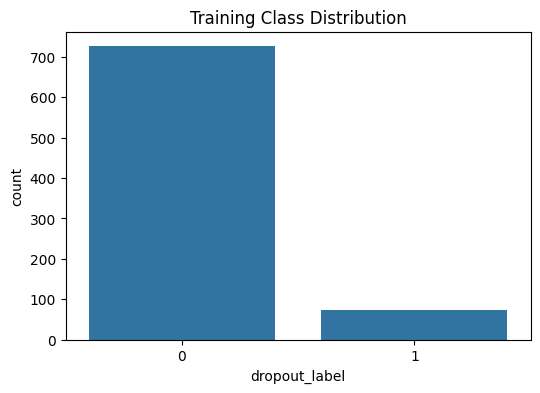

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Class Distribution")

plt.show()

In [46]:
numeric_features=X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features=X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

In [51]:
def evaluate_model(model,
                   X_train,
                   y_train,
                   X_test,
                   y_test):

    # Make copies to avoid modifying original DataFrames globally
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Convert numeric features to numeric, coercing errors to NaN
    # This handles cases where 'numeric_features' might contain strings
    for col in numeric_features:
        if col in X_train_processed.columns:
            X_train_processed[col] = pd.to_numeric(X_train_processed[col], errors='coerce')
        if col in X_test_processed.columns:
            X_test_processed[col] = pd.to_numeric(X_test_processed[col], errors='coerce')

    pipeline=Pipeline([
        ("preprocessor",preprocessor),
        ("classifier",model)
    ])

    pipeline.fit(X_train_processed,y_train)

    pred=pipeline.predict(X_test_processed)

    prob=pipeline.predict_proba(X_test_processed)[:,1]

    return {

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1":f1_score(y_test,pred),

        "ROC_AUC":roc_auc_score(y_test,prob),

        "PR_AUC":average_precision_score(y_test,prob),

        "Pipeline":pipeline
    }

In [52]:
cat_model=CatBoostClassifier(

    random_state=42,

    verbose=0
)

baseline=evaluate_model(

    cat_model,

    X_train,

    y_train,

    X_test,

    y_test
)

In [53]:
X_train_encoded=preprocessor.fit_transform(X_train)

X_test_encoded=preprocessor.transform(X_test)

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 's'

In [54]:
# Make copies to avoid modifying original DataFrames globally
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Convert numeric features to numeric, coercing errors to NaN
# This handles cases where 'numeric_features' might contain strings
for col in numeric_features:
    if col in X_train_processed.columns:
        X_train_processed[col] = pd.to_numeric(X_train_processed[col], errors='coerce')
    if col in X_test_processed.columns:
        X_test_processed[col] = pd.to_numeric(X_test_processed[col], errors='coerce')

X_train_encoded = preprocessor.fit_transform(X_train_processed)
X_test_encoded = preprocessor.transform(X_test_processed)

In [55]:
smote=SMOTE(random_state=42)

X_smote,y_smote=smote.fit_resample(

    X_train_encoded,

    y_train
)

print(pd.Series(y_smote).value_counts())

dropout_label
0    726
1    726
Name: count, dtype: int64


In [56]:
smote_model=CatBoostClassifier(

    random_state=42,

    verbose=0
)

smote_model.fit(X_smote,y_smote)

pred=smote_model.predict(X_test_encoded)

prob=smote_model.predict_proba(X_test_encoded)[:,1]

smote_results={

    "Accuracy":accuracy_score(y_test,pred),

    "Precision":precision_score(y_test,pred),

    "Recall":recall_score(y_test,pred),

    "F1":f1_score(y_test,pred),

    "ROC_AUC":roc_auc_score(y_test,prob),

    "PR_AUC":average_precision_score(y_test,prob)
}

In [57]:
minority=train_df[
    train_df[TARGET]==1
].copy()

print(minority.shape)

(74, 41)


In [58]:
categorical_columns=minority.select_dtypes(
    include="object"
).columns.tolist()

In [60]:
ctgan=CTGAN(

    epochs=500,

    verbose=True
)

minority.dropna(inplace=True)

ctgan.fit(

    minority,

    discrete_columns=categorical_columns
)

Gen. (-00.91) | Discrim. (-01.42): 100%|██████████| 500/500 [01:28<00:00,  5.67it/s]


In [61]:
synthetic=ctgan.sample(500)

synthetic[TARGET]=1

print(synthetic.shape)

(500, 41)


In [62]:
synthetic.to_csv(

    f"{PROJECT_DIR}/ctgan_dropout_500.csv",

    index=False
)

In [63]:
numeric=minority.select_dtypes(
    include=np.number
).columns.tolist()

numeric.remove(TARGET)

comparison=pd.DataFrame({

    "Real Mean":minority[numeric].mean(),

    "Synthetic Mean":synthetic[numeric].mean(),

    "Real Std":minority[numeric].std(),

    "Synthetic Std":synthetic[numeric].std()

})

comparison

,Real Mean,Synthetic Mean,Real Std,Synthetic Std
age_at_start_of_academic_year,9.933333,9.492313,3.046993,3.981835
term_1_attendance,42.066667,46.137776,24.824417,30.284587
term_2_attendance,51.881818,51.440410,18.926873,22.896454
term_3_attendance,31.521212,25.075584,35.200007,42.488388
average_attendance,41.697980,45.513298,25.980297,29.699590
english_exam_score,39.312121,43.114624,13.866231,35.333262
math_exam_score,36.778788,35.125784,17.260681,39.180224
science_exam_score,42.815152,35.624394,11.994142,21.721207
social_studies_exam_score,46.678788,52.461777,11.002777,17.253223
average_exam_score,41.396212,38.563984,9.567564,23.485398


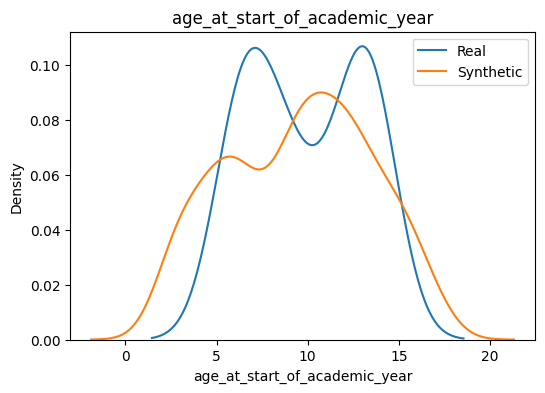

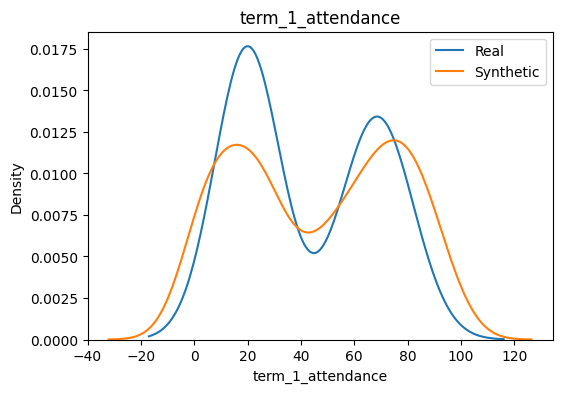

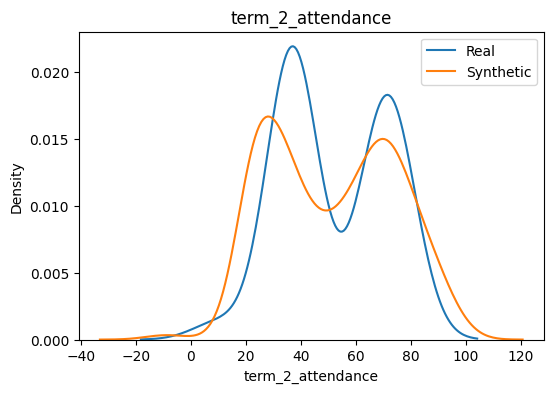

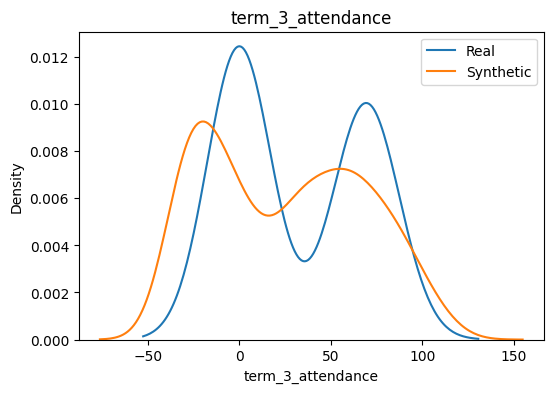

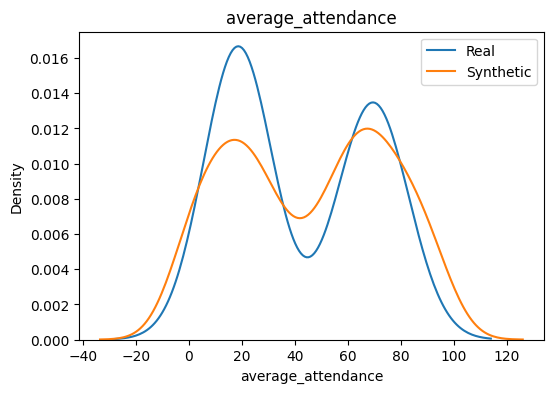

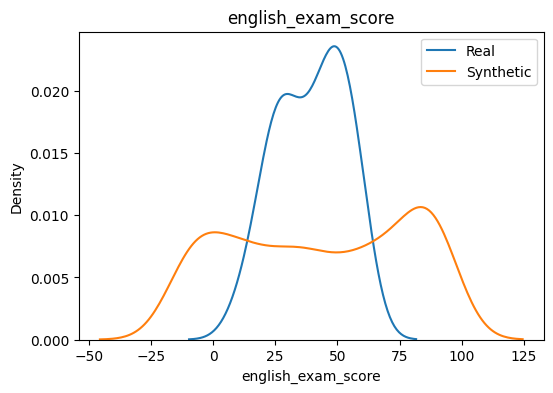

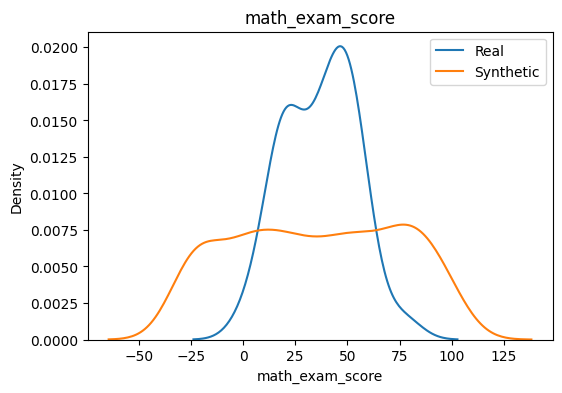

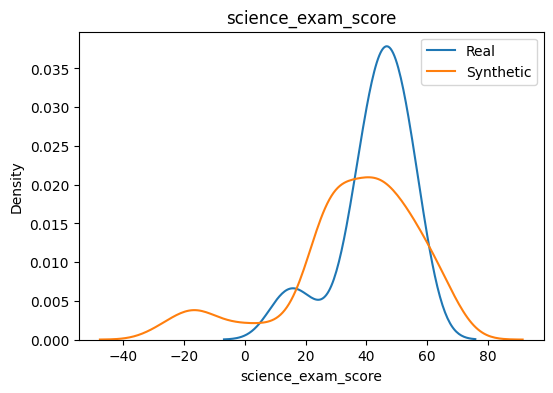

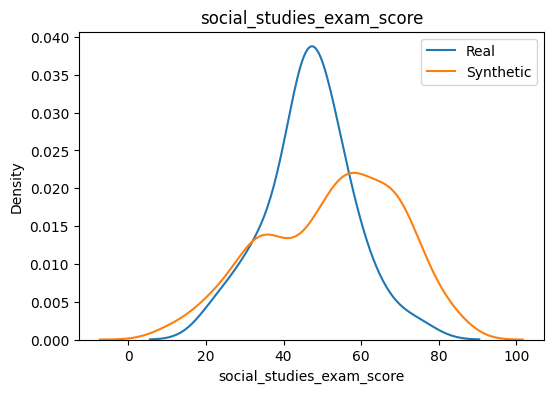

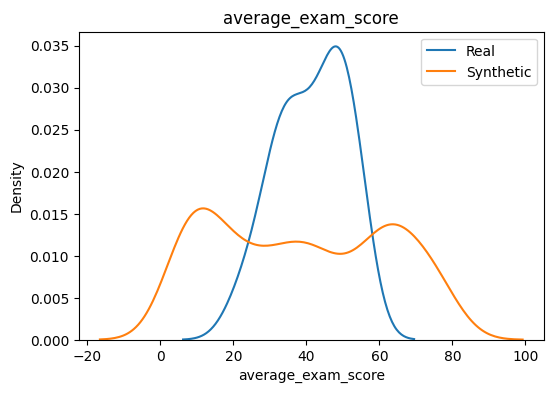

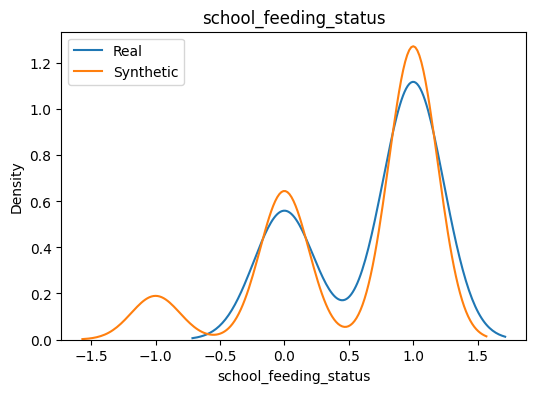

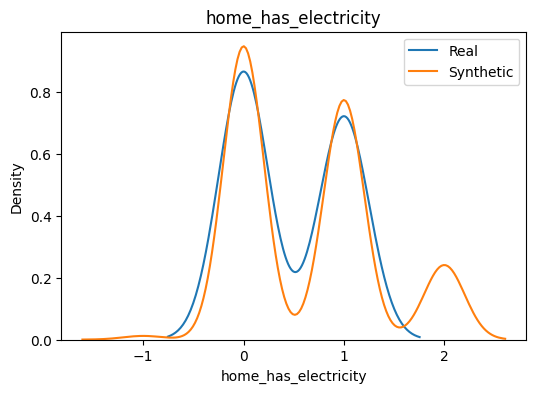

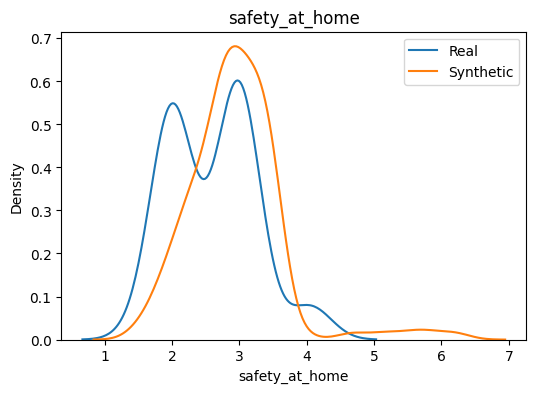

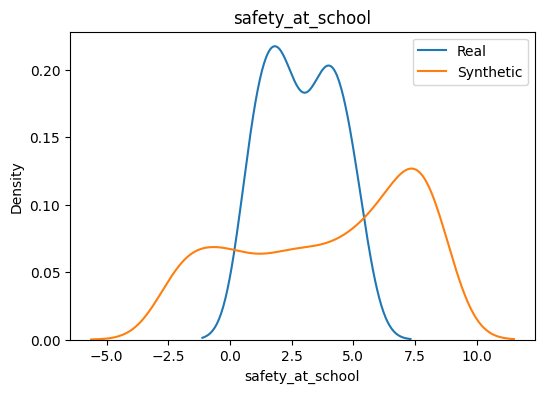

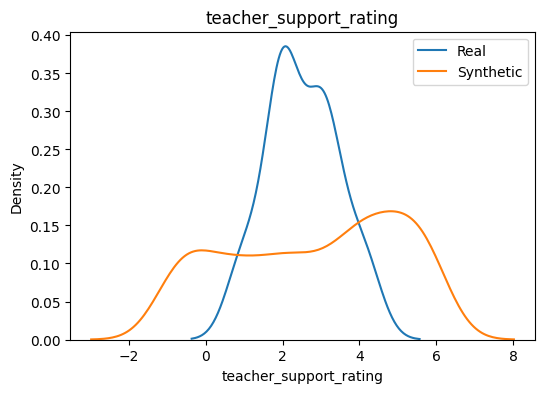

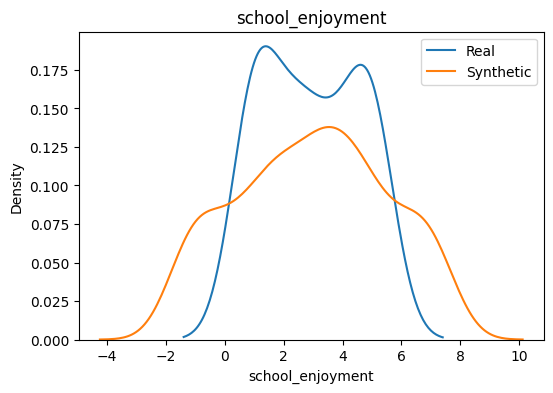

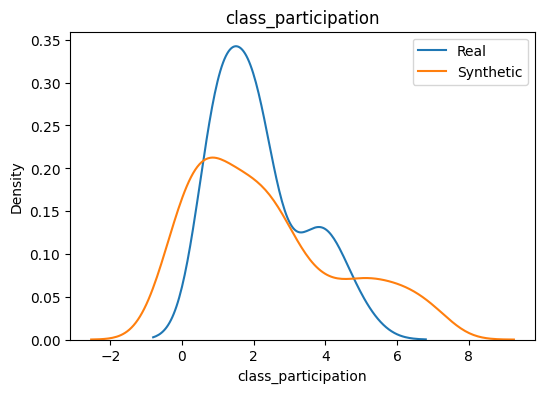

In [64]:
for col in numeric:

    plt.figure(figsize=(6,4))

    sns.kdeplot(minority[col],label="Real")

    sns.kdeplot(synthetic[col],label="Synthetic")

    plt.title(col)

    plt.legend()

    plt.show()

In [65]:
augmented=pd.concat(

    [

        train_df,

        synthetic

    ],

    ignore_index=True
)

print(augmented[TARGET].value_counts())

dropout_label
0    726
1    574
Name: count, dtype: int64


In [66]:
X_aug=augmented.drop(columns=[TARGET])

y_aug=augmented[TARGET]

ctgan_results=evaluate_model(

    CatBoostClassifier(
        random_state=42,
        verbose=0
    ),

    X_aug,

    y_aug,

    X_test,

    y_test
)

In [67]:
results=pd.DataFrame({

    "Experiment":[

        "Original",

        "SMOTE",

        "CTGAN"

    ],

    "Accuracy":[

        baseline["Accuracy"],

        smote_results["Accuracy"],

        ctgan_results["Accuracy"]

    ],

    "Precision":[

        baseline["Precision"],

        smote_results["Precision"],

        ctgan_results["Precision"]

    ],

    "Recall":[

        baseline["Recall"],

        smote_results["Recall"],

        ctgan_results["Recall"]

    ],

    "F1":[

        baseline["F1"],

        smote_results["F1"],

        ctgan_results["F1"]

    ],

    "ROC_AUC":[

        baseline["ROC_AUC"],

        smote_results["ROC_AUC"],

        ctgan_results["ROC_AUC"]

    ],

    "PR_AUC":[

        baseline["PR_AUC"],

        smote_results["PR_AUC"],

        ctgan_results["PR_AUC"]

    ]

})

results

,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Original,0.995,1.0,0.944444,0.971429,0.997863,0.984444
1,SMOTE,0.995,1.0,0.944444,0.971429,0.998474,0.987923
2,CTGAN,0.995,1.0,0.944444,0.971429,0.995421,0.974747


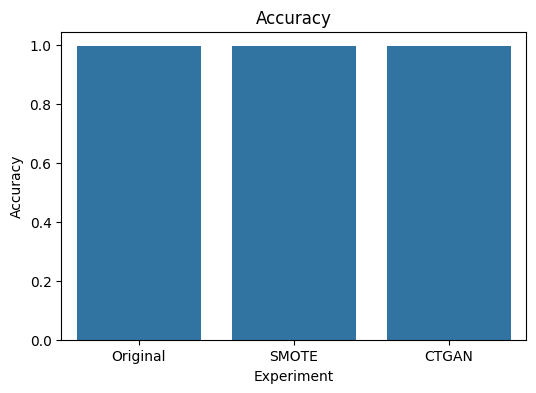

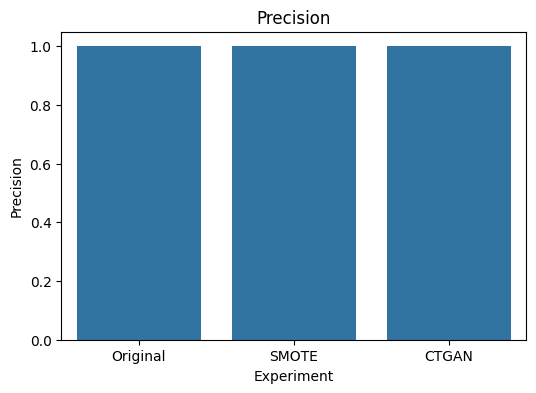

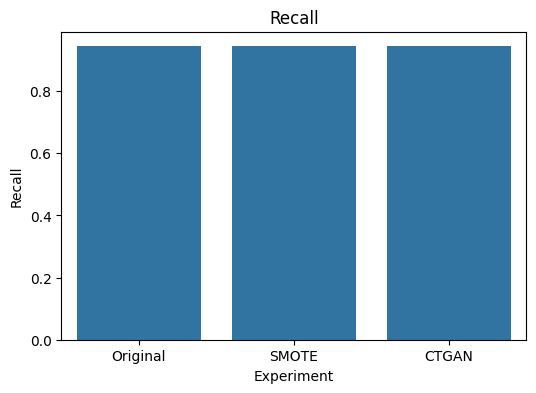

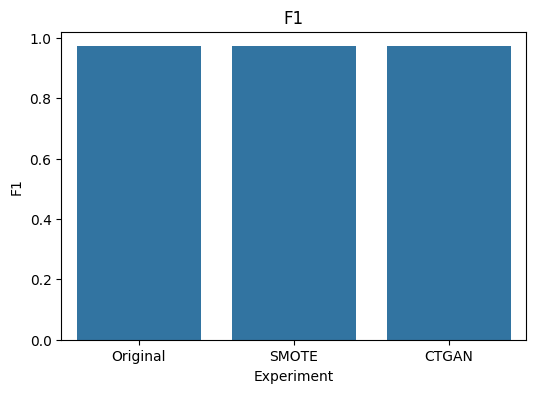

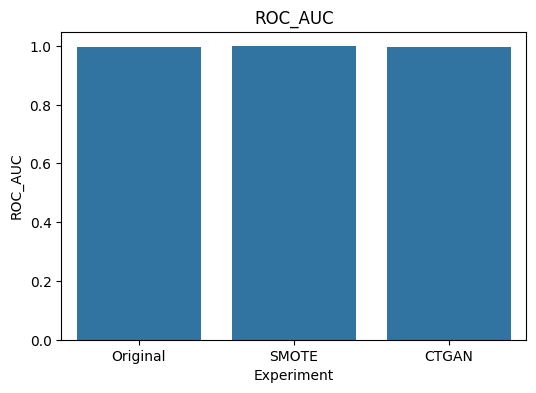

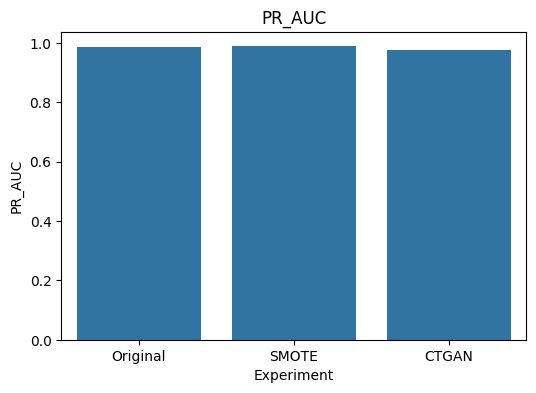

In [68]:
metrics=["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC"]

for metric in metrics:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=results,
        x="Experiment",
        y=metric
    )

    plt.title(metric)

    plt.show()

In [69]:
RESULT_DIR=f"{PROJECT_DIR}/results"

os.makedirs(RESULT_DIR,exist_ok=True)

results.to_csv(

    f"{RESULT_DIR}/augmentation_results.csv",

    index=False
)

joblib.dump(

    baseline["Pipeline"],

    f"{PROJECT_DIR}/models/catboost_original.pkl"
)

print("Notebook 5 completed successfully.")

Notebook 5 completed successfully.
